## DATA PREPROCESSING & EXPLORATION

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

ds = pd.read_csv('../data/info_inspector.csv')
print("The Null values before cleaning:\n", ds.isnull().sum(), "\n")

# missing values for binary flag columns handled by filling with the mode (most frequent value)
cols_with_nulls = ['clinical_note_present', 'lab_report_attached', 'referral_attached', 'policy_criteria_checked']
for col in cols_with_nulls:
    ds[col] = ds[col].fillna(ds[col].mode()[0])

print("The Null values after cleaning:\n", ds.isnull().sum(), "\n")

print("The shape of the dataset is:", ds.shape, "\n")

print(ds.dtypes, "\n")

print("The description of the dataset is:\n", ds.describe(), "\n")

The Null values before cleaning:
 case_id                                          0
payer_family                                     0
request_type                                     0
diagnosis_category                               0
clinical_note_present                         3559
diagnosis_code_present                           0
procedure_code_present                           0
ndc_code_present                                 0
lab_report_attached                           3539
referral_attached                             3558
imaging_report_attached                          0
medication_history_attached                      0
pa_form_signed                                   0
insurance_card_present                           0
provider_npi_present                             0
patient_demographics_complete                    0
policy_criteria_checked                       3647
required_fields_total                            0
missing_required_fields_count                   

## Handling outliers

In [7]:
print(ds['missing_required_fields_count'].value_counts(), "\n")

# Handling outliers using IQR method for 'missing_required_fields_count'
q1 = ds['missing_required_fields_count'].quantile(0.25)
q3 = ds['missing_required_fields_count'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
ds['missing_required_fields_count'] = ds['missing_required_fields_count'].clip(lower=lower, upper=upper)


print(ds['total_documents_attached'].value_counts(), "\n")

# Handling outliers using IQR method for 'total_documents_attached'
q1_doc = ds['total_documents_attached'].quantile(0.25)
q3_doc = ds['total_documents_attached'].quantile(0.75)
iqr_doc = q3_doc - q1_doc
lower_doc = q1_doc - 1.5 * iqr_doc
upper_doc = q3_doc + 1.5 * iqr_doc
ds['total_documents_attached'] = ds['total_documents_attached'].clip(lower=lower_doc, upper=upper_doc)

missing_required_fields_count
1    79352
0    62932
2    42631
3    12438
4     2332
5      287
6       25
7        3
Name: count, dtype: int64 

total_documents_attached
7     50681
8     49159
6     34561
9     31155
5     14970
10    12085
4      3514
11     2388
3       482
12      167
26       54
43       53
33       51
42       48
37       46
25       42
39       41
30       40
35       40
34       39
41       38
29       38
31       38
28       36
44       36
27       36
2        35
40       33
32       33
38       33
36       25
1         3
Name: count, dtype: int64 



## Numerical Data Representation

## BoxPlot of missing required fields

BoxPlot of the missing required fields count Axes(0.125,0.11;0.775x0.77) 



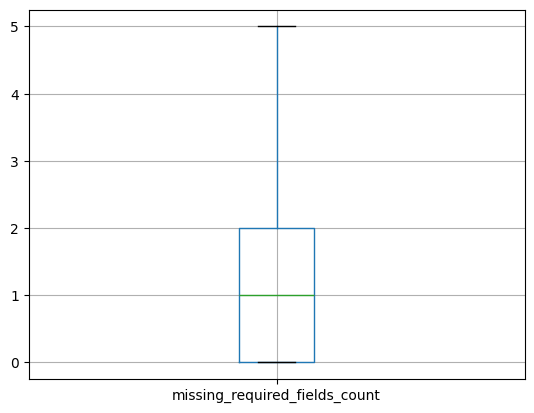

In [8]:
print("BoxPlot of the missing required fields count", ds.boxplot(column='missing_required_fields_count'), "\n")
plt.show()

## BoxPlot of total documents attached

BoxPlot of the total documents attached Axes(0.125,0.11;0.775x0.77) 



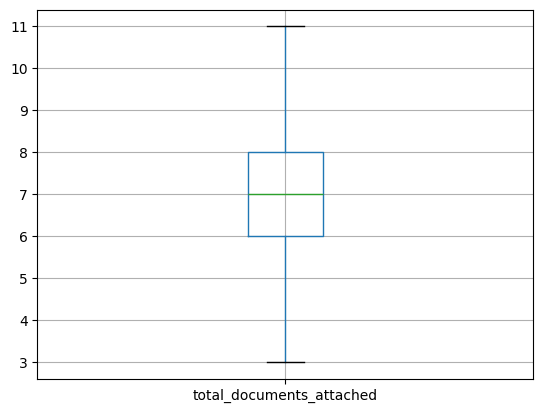

In [9]:
print("BoxPlot of the total documents attached", ds.boxplot(column='total_documents_attached'), "\n")
plt.show()

## Histogram of missing required fields

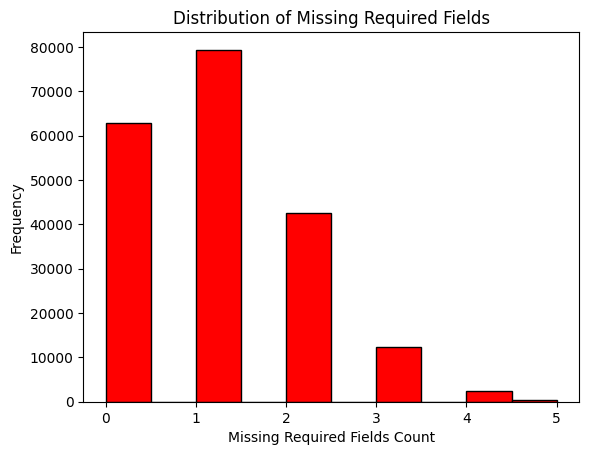

In [10]:
plt.hist(ds['missing_required_fields_count'], bins=10, edgecolor='black', color='red')
plt.xlabel('Missing Required Fields Count')
plt.ylabel('Frequency')
plt.title('Distribution of Missing Required Fields')
plt.show()

## Histogram for total documents attached

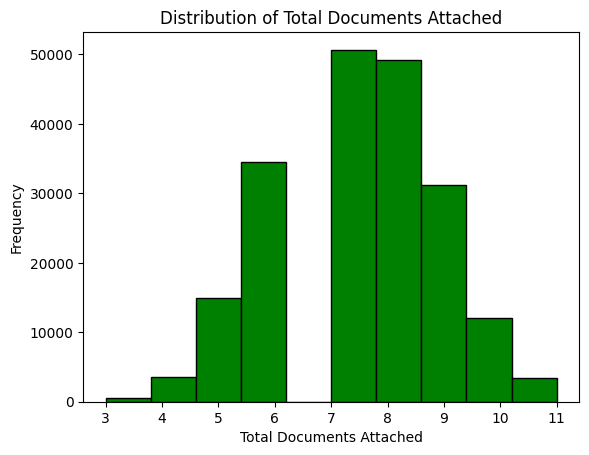

In [11]:
plt.hist(ds['total_documents_attached'], bins=10, edgecolor='black', color='green')
plt.xlabel('Total Documents Attached')
plt.ylabel('Frequency')
plt.title('Distribution of Total Documents Attached')
plt.show()

## Scatter Plot between missing required fields & total documents attached

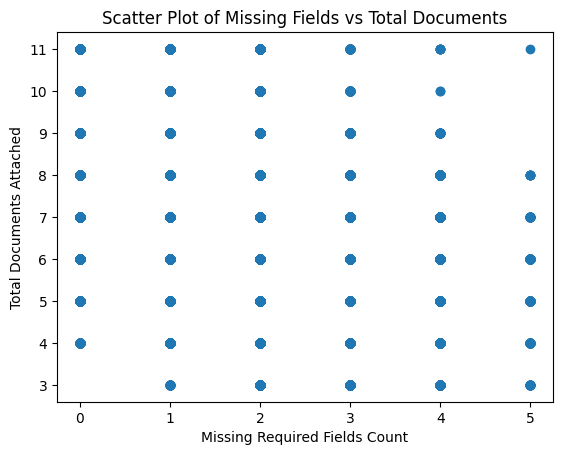

In [12]:
plt.scatter(ds['missing_required_fields_count'], ds['total_documents_attached'])
plt.xlabel('Missing Required Fields Count')
plt.ylabel('Total Documents Attached')
plt.title('Scatter Plot of Missing Fields vs Total Documents')
plt.show()

## Categorical Data Representation
## Bar Graphs:

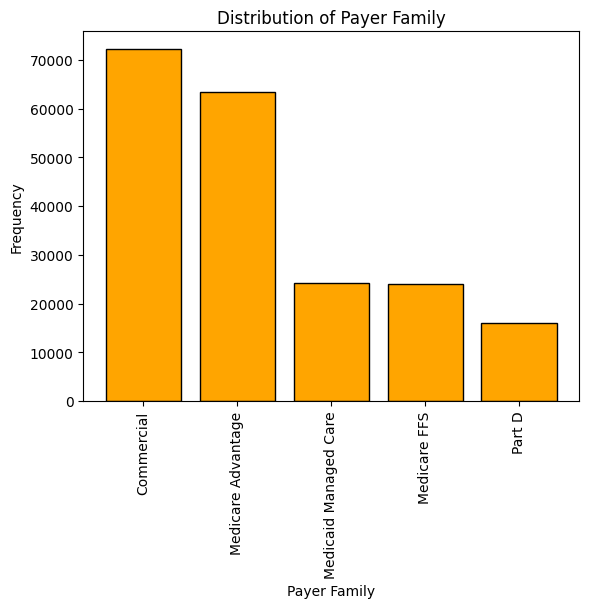

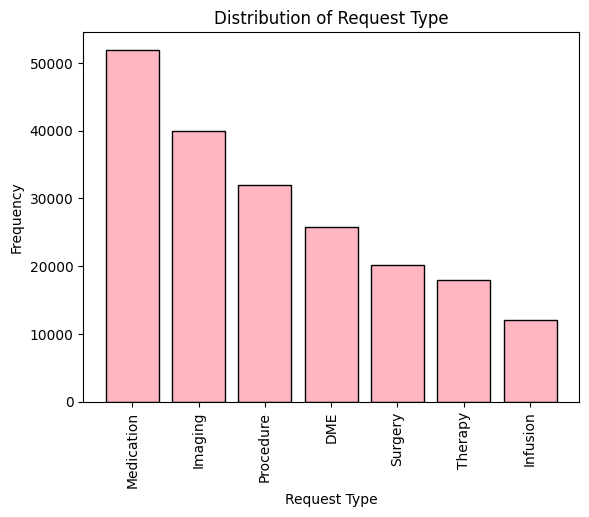

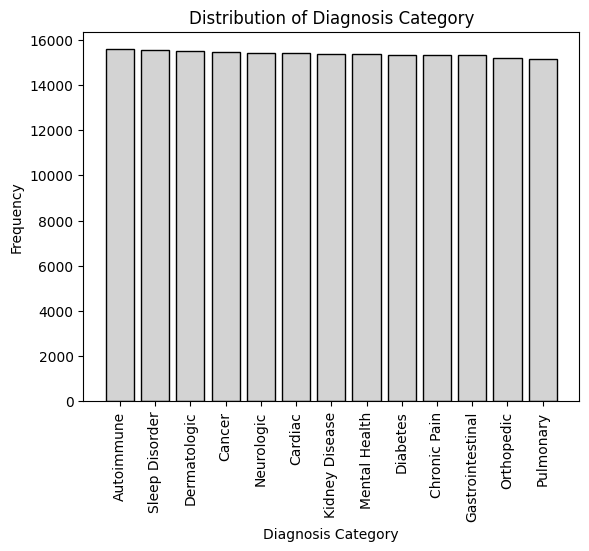

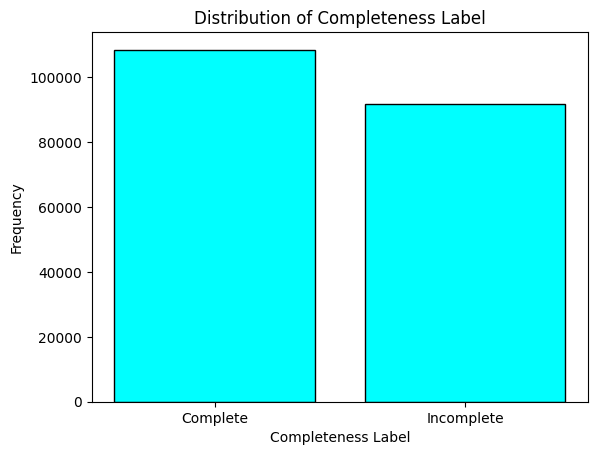

In [13]:
payer_family_dict = ds['payer_family'].value_counts().to_dict()
request_type_dict = ds['request_type'].value_counts().to_dict()
diagnosis_category_dict = ds['diagnosis_category'].value_counts().to_dict()
completeness_label_dict = ds['completeness_label'].value_counts().to_dict()

plt.bar(payer_family_dict.keys(), payer_family_dict.values(), color='orange', edgecolor='black')
plt.xlabel('Payer Family')
plt.ylabel('Frequency')
plt.title('Distribution of Payer Family')
plt.xticks(rotation=90)
plt.show()

plt.bar(request_type_dict.keys(), request_type_dict.values(), color='lightpink', edgecolor='black')
plt.xlabel('Request Type')
plt.ylabel('Frequency')
plt.title('Distribution of Request Type')
plt.xticks(rotation=90)
plt.show()

plt.bar(diagnosis_category_dict.keys(), diagnosis_category_dict.values(), color='lightgray', edgecolor='black')
plt.xlabel('Diagnosis Category')
plt.ylabel('Frequency')
plt.title('Distribution of Diagnosis Category')
plt.xticks(rotation=90)
plt.show()

plt.bar(completeness_label_dict.keys(), completeness_label_dict.values(), color='cyan', edgecolor='black')
plt.xlabel('Completeness Label')
plt.ylabel('Frequency')
plt.title('Distribution of Completeness Label')
plt.show()

## Categorical Data Pie Charts

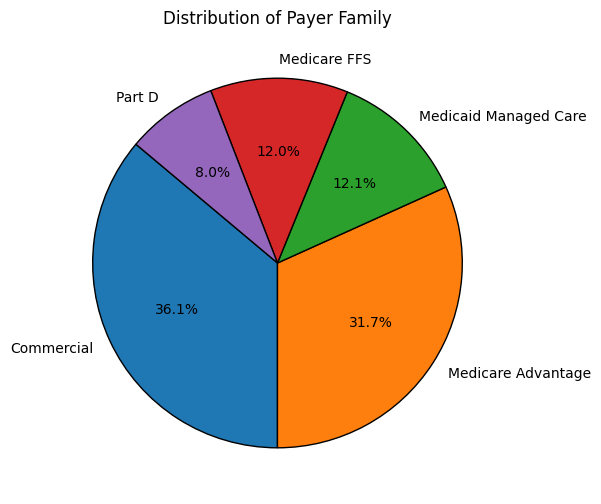

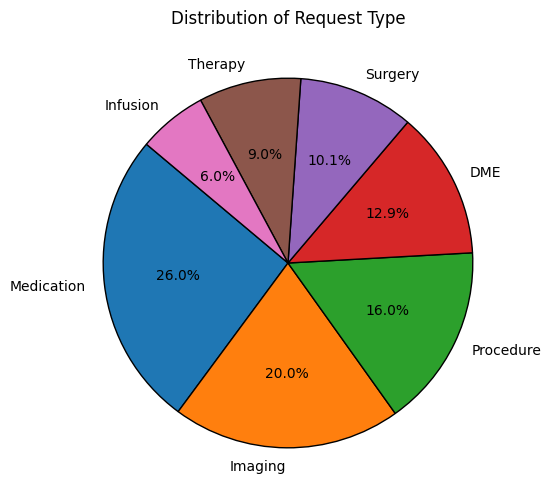

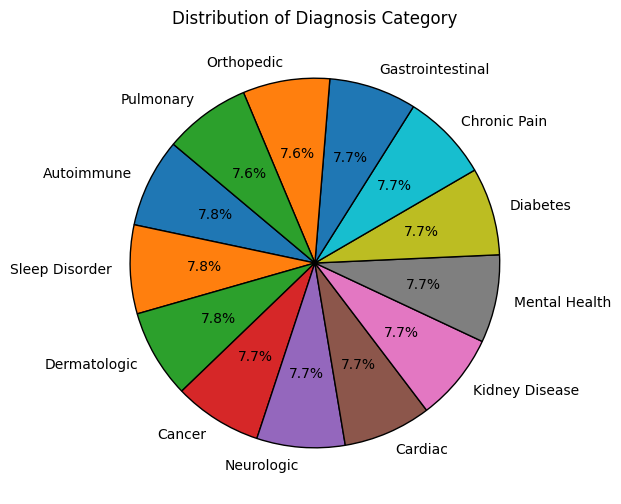

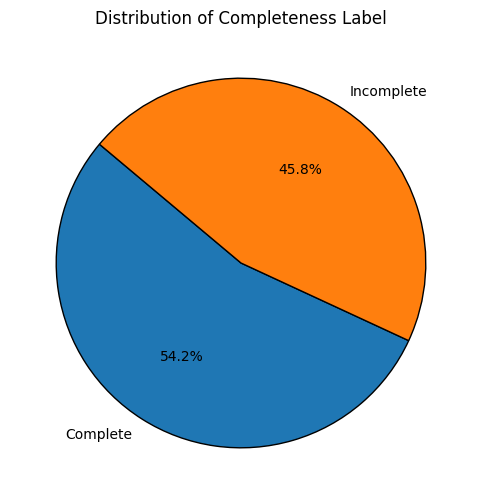

In [14]:
# Payer Family
plt.figure(figsize=(8,6))
plt.pie(payer_family_dict.values(), labels=payer_family_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Payer Family')
plt.show()

# Request Type
plt.figure(figsize=(8,6))
plt.pie(request_type_dict.values(), labels=request_type_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Request Type')
plt.show()

# Diagnosis Category
plt.figure(figsize=(8,6))
plt.pie(diagnosis_category_dict.values(), labels=diagnosis_category_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Diagnosis Category')
plt.show()

# Completeness Label
plt.figure(figsize=(8,6))
plt.pie(completeness_label_dict.values(), labels=completeness_label_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Completeness Label')
plt.show()

## Pair Plot for Document Completeness

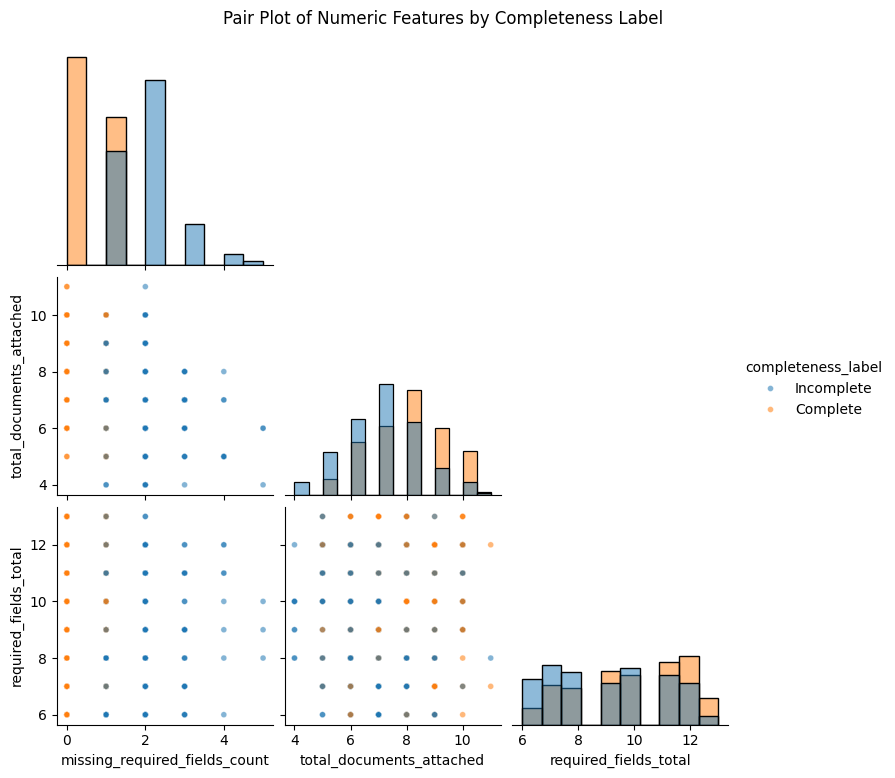

In [15]:
import seaborn as sns

pair_plot_features = ['missing_required_fields_count', 'total_documents_attached', 'required_fields_total']
pair_plot_cols = pair_plot_features + ['completeness_label']

pair_plot_data = ds[pair_plot_cols].dropna()
pair_plot_sample = (
    pair_plot_data
    .sample(frac=1, random_state=42)
    .groupby('completeness_label', group_keys=False)
    .head(250)
    .reset_index(drop=True)
)

sns.pairplot(
    pair_plot_sample,
    vars=pair_plot_features,
    hue='completeness_label',
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.55, 's': 18},
)
plt.suptitle('Pair Plot of Numeric Features by Completeness Label', y=1.03)
plt.show()

## First Machine Learning Model: Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = ds.drop(columns=['case_id', 'payer_family', 'request_type', 'diagnosis_category', 
                     'document_completeness_score_true_synthetic', 'completeness_label'])
y = ds['completeness_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred), "\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.88455 

Classification Report:
               precision    recall  f1-score   support

    Complete       0.88      0.91      0.90     21706
  Incomplete       0.89      0.85      0.87     18294

    accuracy                           0.88     40000
   macro avg       0.89      0.88      0.88     40000
weighted avg       0.88      0.88      0.88     40000

